# 🚌 Montreal STM Transit Delay Predictor
### Automated Performance Dashboard & Analysis
**Objective:** Predict transit delays based on historical STM data and real-time weather conditions.

**Pipeline Status:**
- **Data Collection:** Automated via `src/stm_collector.py`
- **Model Training:** Automated via `train_model.py`
- **Orchestration:** Managed by `run_pipeline.py`

This dashboard visualizes the health of our model and provides exploratory insights into Montreal's transit patterns.

### 1. Setup & Environment
We import the necessary data science libraries to load our model, analyze the data logs, and visualize the performance metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from datetime import datetime
from sklearn.metrics import mean_absolute_error

# Configure visual style
plt.style.use('ggplot')

---

### 2. Model Performance Tracking
This chart tracks the accuracy of our model over time. 
- **MAE (Mean Absolute Error):** Represents the average error in minutes. 
- **RMSE (Root Mean Squared Error):** Gives more weight to larger errors, helping us spot if the model is failing badly on specific extreme cases.

*Goal: We want these lines to trend downward as the model "learns" from more data.*

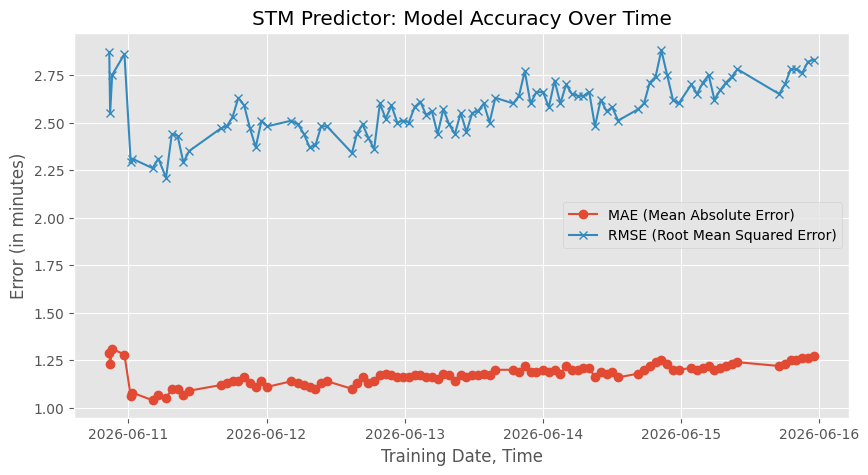

In [2]:
# Load the historical performance log
log_path = 'data_collection/ml_model_performance_log.csv'
if os.path.exists(log_path):
    perf = pd.read_csv(log_path)
    perf['timestamp'] = pd.to_datetime(perf['timestamp'])

    # Plot the results
    plt.figure(figsize=(10, 5))
    plt.plot(perf['timestamp'], perf['mae'], label='MAE (Mean Absolute Error)', marker='o')
    plt.plot(perf['timestamp'], perf['rmse'], label='RMSE (Root Mean Squared Error)', marker='x')
    
    plt.title("STM Predictor: Model Accuracy Over Time")
    plt.xlabel("Training Date, Time")
    plt.ylabel("Error (in minutes)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Performance log not found. Ensure the pipeline has run at least once.")

---

### 3. Model Inference & Feature Importance
Instead of training, we load the "frozen" model (the `.pkl` file) produced by our background pipeline. 

The coefficients below show us which aspects of the weather the model believes are most important in predicting delays. A higher weight indicates that the feature has a stronger impact on the predicted travel time.

In [3]:
# Load the model from your new folder
model_path = 'model_versions/transit_model.pkl'

if os.path.exists(model_path):
    model = joblib.load(model_path)
    print("Model loaded successfully!")
    
    # If it's a Linear Regression model, show the importance of each feature
    # (assuming you trained it with feature names)
    if hasattr(model, 'feature_names_in_'):
        features = model.feature_names_in_
        coefficients = model.coef_
        importance = pd.DataFrame({'Feature': features, 'Weight': coefficients})
        print(importance.sort_values(by='Weight', ascending=False))
else:
    print("Model file not found. Ensure train_model.py has run.")

Model loaded successfully!
      Feature        Weight
0        temp  3.582508e-02
5        wspd  1.662880e-02
9        cldc  1.142329e-02
11       Hour  1.009128e-03
10       coco  5.891228e-04
3        snwd  2.289835e-16
8        tsun  1.908196e-17
4        wdir -1.386518e-03
6        wpgt -5.093989e-03
1        rhum -6.154291e-03
7        pres -2.207562e-02
12  DayOfWeek -5.045435e-02
2        prcp -3.147689e-01


---

### 4. Exploratory Data Analysis (EDA)
Here, we look at the raw data to generate human-readable insights. We aggregate travel times by hour of the day to identify "rush hour" trends and determine if the STM's performance remains consistent across the entire day.

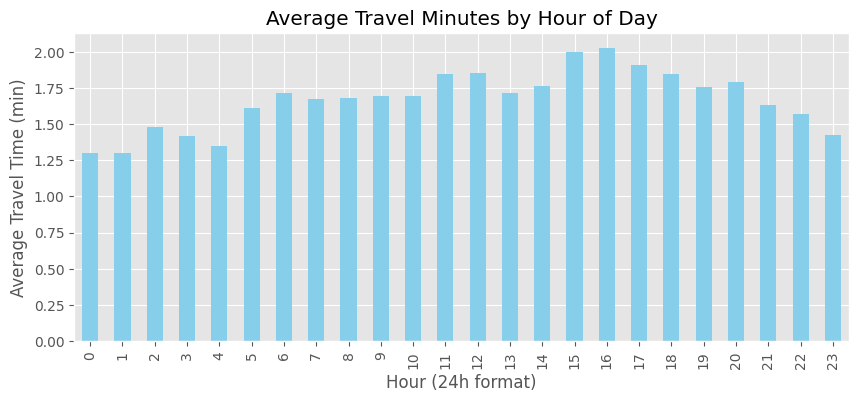

In [4]:
# Load the main travel dataset
df = pd.read_csv('data_collection/stm_travel_time.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Quick peak at delays by hour
df['hour'] = df['timestamp'].dt.hour
hourly_delay = df.groupby('hour')['travel_minutes'].mean()

plt.figure(figsize=(10, 4))
hourly_delay.plot(kind='bar', color='skyblue')
plt.title("Average Travel Minutes by Hour of Day")
plt.xlabel("Hour (24h format)")
plt.ylabel("Average Travel Time (min)")
plt.show()

In [5]:
df = pd.read_csv('data_collection/stm_travel_time.csv')

# Baseline
mean_travel_time = df['travel_minutes'].mean()
baseline_predictions = [mean_travel_time] * len(df)
baseline_mae = mean_absolute_error(df['travel_minutes'], baseline_predictions)

# Pull most recent MAE from performance log
perf = pd.read_csv('data_collection/ml_model_performance_log.csv')
your_model_mae = perf['mae'].iloc[-1]

# Compare
improvement_pct = (baseline_mae - your_model_mae) / baseline_mae * 100

print(f"Mean travel time (baseline guess): {mean_travel_time:.2f} min")
print(f"Baseline MAE: {baseline_mae:.2f} min")
print(f"Your model MAE: {your_model_mae:.2f} min")
print(f"Improvement over baseline: {improvement_pct:.1f}%")

Mean travel time (baseline guess): 1.70 min
Baseline MAE: 1.24 min
Your model MAE: 1.27 min
Improvement over baseline: -2.2%
